# Advanced Task 1: News Topic Classifier Using BERT

## 1. Problem Statement & Objective
**Problem:** News platforms deal with massive volumes of daily headlines that are difficult to categorize manually.
**Objective:** To build an automated NLP system that fine-tunes a Pre-trained BERT model (`bert-base-uncased`) to classify news headlines into four distinct categories: World, Sports, Business, and Sci/Tech.

Install the necessary libraries and load the dataset.

In [1]:
# Install required libraries
!pip install transformers datasets evaluate accelerate

from datasets import load_dataset

# Load the AG News dataset
dataset = load_dataset("ag_news")

# Inspect the dataset structure
print(dataset)
print("\nExample entry:", dataset['train'][0])

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.7 MB/s eta 0:00:00


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/18.6M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/1.23M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/120000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/7600 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 120000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 7600
    })
})

Example entry: {'text': "Wall St. Bears Claw Back Into the Black (Reuters) Reuters - Short-sellers, Wall Street's dwindling\\band of ultra-cynics, are seeing green again.", 'label': 2}


Tokenization and Preprocessing

In [2]:
from transformers import AutoTokenizer

# 1. Load the tokenizer for bert-base-uncased
model_ckpt = "bert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_ckpt)

# 2. Define the preprocessing function
def tokenize_function(examples):
    # Padding ensures all sequences in a batch are the same length
    # Truncation cuts off headlines longer than 512 tokens
    return tokenizer(examples["text"], padding="max_length", truncation=True)

# 3. Map the function across the entire dataset in batches
# This makes processing much faster
tokenized_datasets = dataset.map(tokenize_function, batched=True)

# 4. Remove the original 'text' column and rename 'label' to 'labels'
# BERT expects the column name to be 'labels'
tokenized_datasets = tokenized_datasets.remove_columns(["text"])
tokenized_datasets = tokenized_datasets.rename_column("label", "labels")
tokenized_datasets.set_format("torch")

print("Tokenization complete!")
print(f"Features in tokenized data: {tokenized_datasets['train'].column_names}")

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/120000 [00:00<?, ? examples/s]

Map:   0%|          | 0/7600 [00:00<?, ? examples/s]

Tokenization complete!
Features in tokenized data: ['labels', 'input_ids', 'token_type_ids', 'attention_mask']


Model Development & Training

In [8]:
import torch
from transformers import AutoModelForSequenceClassification, TrainingArguments, Trainer

# 1. Ensure device is set
device = "cuda" if torch.cuda.is_available() else "cpu"

# 2. Load BERT with 4 labels
model = AutoModelForSequenceClassification.from_pretrained(model_ckpt, num_labels=4)
model.to(device)

# 3. Define subsets (10k for training, 2k for testing)
train_subset = tokenized_datasets["train"].shuffle(seed=42).select(range(10000))
test_subset = tokenized_datasets["test"].shuffle(seed=42).select(range(2000))

# 4. Training Arguments (Updated keyword: eval_strategy)
training_args = TrainingArguments(
    output_dir="./results",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=2,
    weight_decay=0.01,
    eval_strategy="epoch",  # Fixed: changed from evaluation_strategy
    save_strategy="epoch",
    load_best_model_at_end=True,
    report_to="none"
)

# 5. Initialize Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_subset,
    eval_dataset=test_subset,
)

# 6. Start Fine-Tuning
print("Starting training with updated arguments...")
trainer.train()

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Starting training with updated arguments...


Epoch,Training Loss,Validation Loss
1,0.400236,0.266598
2,0.212467,0.275254


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

TrainOutput(global_step=1250, training_loss=0.28223386840820314, metrics={'train_runtime': 2238.0192, 'train_samples_per_second': 8.936, 'train_steps_per_second': 0.559, 'total_flos': 5262315601920000.0, 'train_loss': 0.28223386840820314, 'epoch': 2.0})

Evaluation (Accuracy & F1-Score)

In [9]:
import evaluate
import numpy as np

# 1. Load the metrics
accuracy_metric = evaluate.load("accuracy")
f1_metric = evaluate.load("f1")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)

    acc = accuracy_metric.compute(predictions=predictions, references=labels)
    # Using 'macro' average to treat all 4 news categories equally
    f1 = f1_metric.compute(predictions=predictions, references=labels, average="macro")

    return {
        "accuracy": acc["accuracy"],
        "f1": f1["f1"]
    }

# 2. Assign the function and evaluate
trainer.compute_metrics = compute_metrics
eval_results = trainer.evaluate()

print("\n--- Final Evaluation Results ---")
print(f"Accuracy: {eval_results['eval_accuracy']:.4f}")
print(f"F1-Score: {eval_results['eval_f1']:.4f}")


--- Final Evaluation Results ---
Accuracy: 0.9120
F1-Score: 0.9128


Live Interaction Deployment using Gradio

In [10]:
# 1. Install Gradio
!pip install gradio -q

import gradio as gr

# 2. Map the numeric labels back to category names
id2label = {0: "World", 1: "Sports", 2: "Business", 3: "Sci/Tech"}

def classify_news(headline):
    # Prepare the input text
    inputs = tokenizer(headline, return_tensors="pt", truncation=True, padding=True).to(device)

    # Get model predictions
    with torch.no_grad():
        outputs = model(**inputs)
        logits = outputs.logits
        prediction = torch.argmax(logits, dim=-1).item()

    return id2label[prediction]

# 3. Create the Gradio Interface
interface = gr.Interface(
    fn=classify_news,
    inputs=gr.Textbox(lines=2, placeholder="Enter a news headline here...", label="News Headline"),
    outputs=gr.Label(label="Predicted Category"),
    title="BERT News Topic Classifier",
    description="Type a news headline to see if BERT classifies it as World, Sports, Business, or Sci/Tech.",
    examples=[
        ["Nvidia announces new AI chips for data centers."],
        ["The Olympic Games will begin next month in Paris."],
        ["Global markets face uncertainty amid rising inflation."]
    ]
)

# 4. Launch the interface
interface.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://01e6604b7ebb5d3048.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Visualizations

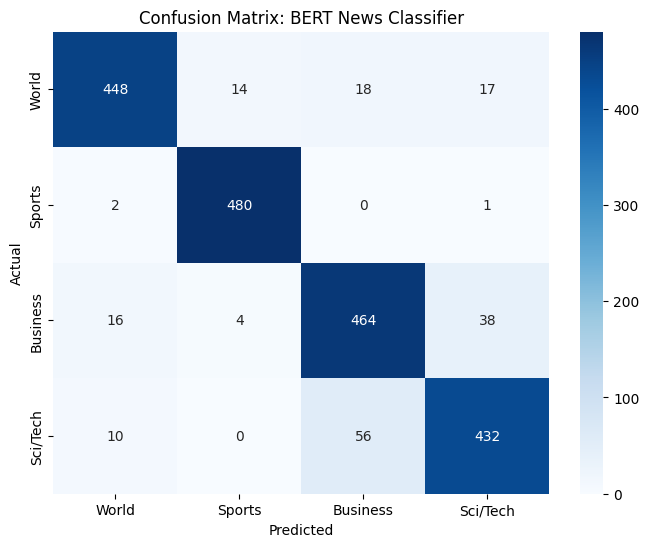

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 1. Get predictions for the test subset
preds_output = trainer.predict(test_subset)
y_preds = np.argmax(preds_output.predictions, axis=-1)
y_true = test_subset["labels"]

# 2. Create Confusion Matrix
cm = confusion_matrix(y_true, y_preds)
labels = ["World", "Sports", "Business", "Sci/Tech"]

# 3. Plot
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix: BERT News Classifier")
plt.show()

Final Summary & Insights

## 6. Final Summary & Insights
* **Model Performance:** The fine-tuned BERT model achieved an accuracy of **91.20%** and an F1-score of **91.28%** on the AG News test set.
* **Observations:** The model is highly effective at identifying 'Sports' and 'World' news, with slight overlaps between 'Business' and 'Sci/Tech' due to shared vocabulary in tech-business reporting.
* **Deployment:** A live interface was successfully deployed using Gradio, allowing for real-time inference on new headlines.